In [63]:
## Load libraries
from src.gtfs_stops_ingestion import load_gtfs_stops
from src.otp_travel_time import get_time
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

## Input contract

This notebook assumes as input a **GeoDataFrame of points** with the following properties:

- Each row represents a **hexagon centroid**
- A unique and non-null `point_id` column exists
- The active geometry is of type **Point**
- The CRS matches the **project canonical CRS**

⚠️ **If any of these conditions are not met, the analysis is not valid.**

In [64]:
## Global parameters
PROJECT_CRS = "EPSG:4326"  # Project canonical CRS
METRIC_CRS = "EPSG:3763"   # CRS for planar projection
RADIO_WALK = 4000          # Geometric radius-based pre-filter for points
OTP_BASE_URL = "http://otp-serve:8080/otp/gtfs/v1"
MODE = "WALK"              # WALK, BICYCLE or TRANSIT
WALK_DATETIME = "2025-12-10T08:00:00Z"

In [65]:
points = gpd.read_file("/results/points_hex_500m_wgs84.geojson")
zip_path_mdp = "/data/mdp_gtfs.zip"

In [66]:
assert isinstance(points, gpd.GeoDataFrame), "Input is not a GeoDataFrame"
assert points.geom_type.unique().tolist() == ["Point"], "Geometry is not Point"
assert points.crs == PROJECT_CRS, "Incorrect CRS in points"
assert "point_id" in points.columns, "Missing point_id column"
assert points["point_id"].is_unique, "point_id is not unique"
assert points["point_id"].isna().sum() == 0, "point_id contains null values"

In [67]:
## Load and convert GTFS stops to geometry (canonical CRS)
stops_gdf = load_gtfs_stops(
    zip_path=zip_path_mdp,
    txt_filename="stops.txt",
    PROJECT_CRS=PROJECT_CRS
)

# Reproject points and stations to a projected CRS
points_m = points.to_crs(METRIC_CRS)
stops_m = stops_gdf.to_crs(METRIC_CRS)

In [68]:
## Pre-calculation of the number of WALK combinations
assert points_m.crs == METRIC_CRS
assert stops_m.crs == METRIC_CRS

rows = []
total = 0
processed = 0

for _, p in points_m.iterrows():
    total += stops_m.distance(p.geometry).le(RADIO_WALK).sum()

print(f"Actual total number of WALK combinations: {total}")

Actual total number of WALK combinations: 6329


In [69]:
## Calculation of travel times (point–stop)
def compute_point_station(p, s):
    t = get_time(
        lat=p["lat"],
        lon=p["lon"],
        dest_lat=s["stop_lat"],
        dest_lon=s["stop_lon"],
        mode=MODE,
        base_url=OTP_BASE_URL,
        datetime_iso=WALK_DATETIME
    )

    if t is None:
        return {
            "point_id": p["point_id"],
            "station_id": s["stop_id"],
            "duration_min": None,
            "distance_m": None,
            "by_mode": None
        }

    return {
        "point_id": p["point_id"],
        "station_id": s["stop_id"],
        "duration_min": t["total"]["duration_min"],
        "distance_m": t["total"]["distance_m"],
        "by_mode": t["by_mode"]
    }

In [70]:
## Test functions
print(get_time(
    lat=41.16353,
    lon=-8.654582,
    dest_lat=41.16432,
    dest_lon=-8.617664,
    mode=MODE,
    base_url=OTP_BASE_URL,
    datetime_iso=WALK_DATETIME
))

{'total': {'distance_m': 3626.26, 'duration_min': 61.92}, 'by_mode': {'WALK': {'distance_m': 3626.26, 'duration_min': 61.92}}}


In [71]:
## Parallel execution of WALK travel time queries
max_workers = 12
processed = 0

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    for idx_p, p in points_m.iterrows():

        # filtro geométrico
        candidate_stops = stops_m[
            stops_m.geometry.distance(p.geometry) <= RADIO_WALK
        ]

        if candidate_stops.empty:
            continue

        futures = [
            executor.submit(compute_point_station, p, s)
            for _, s in candidate_stops.iterrows()
        ]

        for f in as_completed(futures):
            try:
                rows.append(f.result())
            except Exception:
                pass
            processed += 1
            if processed % 50 == 0 or processed == total:
                print(f"Processing {processed}/{total}", end="\r", flush=True)

In [72]:
## Post-processing of WALK travel times
df = pd.DataFrame(rows)

# Remove routes without a valid travel time (no route / error / timeout).
# From this point on, only combinations with computed WALK times are analyzed.
df = df.dropna(subset=["duration_min"])

# Stations reachable within ≤30 minutes walking
df_30 = df[df["duration_min"] <= 30]

# Count per point (≤30 minutes)
n30 = (
    df_30
    .groupby("point_id")
    .size()
    .reset_index(name="n_metro_30min_walk")
)

# Stations reachable within ≤15 minutes walking
df_15 = df[df["duration_min"] <= 15]

# Count per point (≤15 minutes)
n15 = (
    df_15
    .groupby("point_id")
    .size()
    .reset_index(name="n_metro_15min_walk")
)

In [73]:
## Integration of WALK results
points_plot = points.merge(
    n30,
    on="point_id",
    how="left"
)

points_plot = points_plot.merge(
    n15,
    on="point_id",
    how="left"
)

# Points are considered accessible if they have at least one station
# reachable within ≤30 minutes walking.
points_accessible = points_plot[
    points_plot["n_metro_30min_walk"] > 0
]

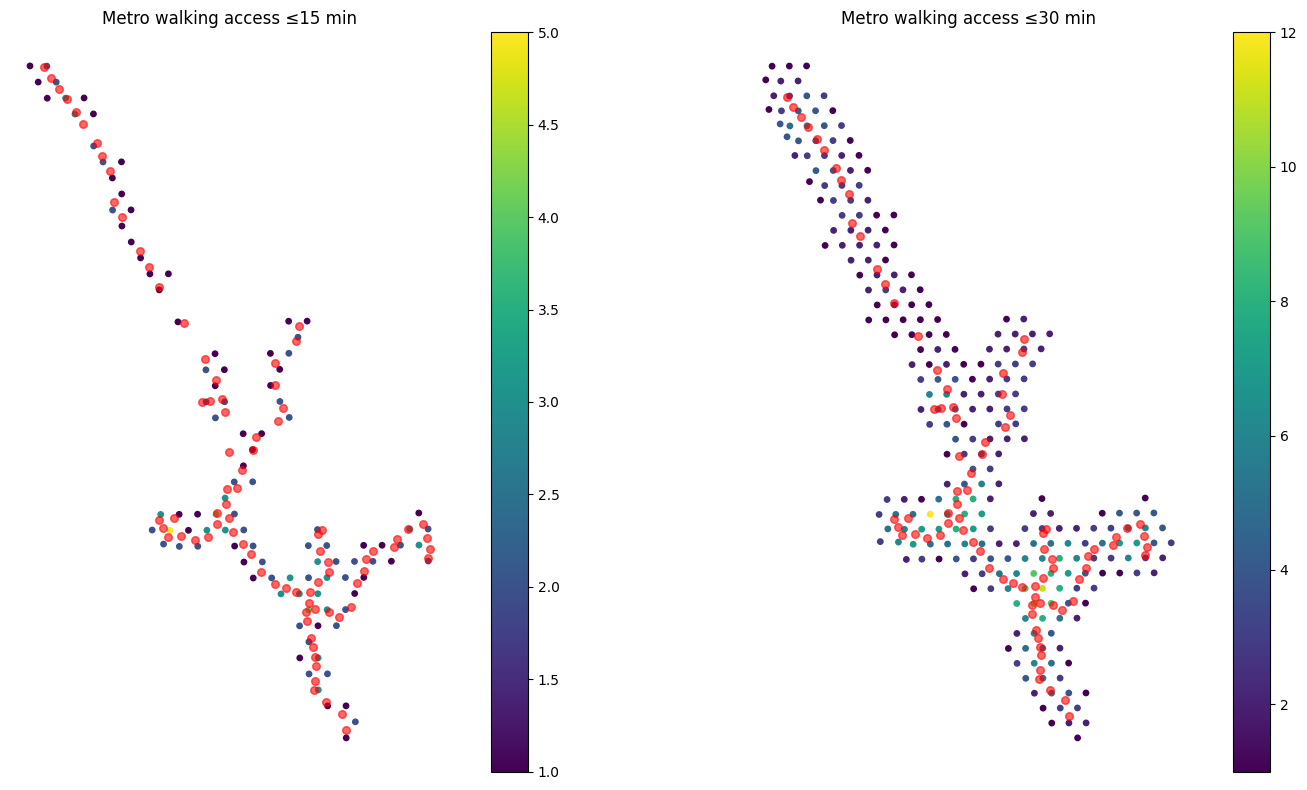

In [74]:
## Plot aggregated points with number of stations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ≤15 min
points_accessible.plot(
    column="n_metro_15min_walk",
    ax=axes[0],
    cmap="viridis",
    markersize=15,
    legend=True
)

stops_gdf.plot(
    ax=axes[0],
    color="red",
    markersize=30,
    alpha=0.6
)

axes[0].set_title("Metro walking access ≤15 min")
axes[0].axis("off")

# ≤30 min
points_accessible.plot(
    column="n_metro_30min_walk",
    ax=axes[1],
    cmap="viridis",
    markersize=15,
    legend=True
)

stops_gdf.plot(
    ax=axes[1],
    color="red",
    markersize=30,
    alpha=0.6
)

axes[1].set_title("Metro walking access ≤30 min")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [75]:
## WALK accessibility synthesis
df_walk = df[
    (df["duration_min"].notna()) &
    (df["duration_min"] <= 30)
].copy()

# For the WALK mode, the minimum time to the nearest station is used,
# given the deterministic nature of walking and its role as a structural
# access mechanism to the transport network.
df_best = (
    df_walk
    .sort_values(["point_id", "duration_min"])
    .groupby("point_id", as_index=False)
    .first()
)

df_final = (
    df_best
    .merge(n15, on="point_id", how="left")
    .merge(n30, on="point_id", how="left")
)

cols = ["n_metro_15min_walk", "n_metro_30min_walk"]

df_final[cols] = df_final[cols].fillna(0).astype(int)

df_final = df_final.rename(columns={
    "station_id": "best_station_walk",
    "duration_min": "t_walk_min"
})

df_final.head(10)

,point_id,best_station_walk,t_walk_min,distance_m,by_mode,n_metro_15min_walk,n_metro_30min_walk
0,4835,5813,26.13,1524.57,"{'WALK': {'distance_m': 1524.57, 'duration_min...",0,1
1,4890,5813,24.23,1432.89,"{'WALK': {'distance_m': 1432.89, 'duration_min...",0,1
2,4891,5813,8.87,425.05,"{'WALK': {'distance_m': 425.05, 'duration_min'...",1,2
3,4892,5813,27.60,1599.68,"{'WALK': {'distance_m': 1599.68, 'duration_min...",0,2
4,4953,5812,29.03,1688.39,"{'WALK': {'distance_m': 1688.39, 'duration_min...",0,1
5,4954,5813,16.32,954.44,"{'WALK': {'distance_m': 954.44, 'duration_min'...",0,3
6,4955,5813,14.32,895.68,"{'WALK': {'distance_m': 895.68, 'duration_min'...",2,3
7,5019,5792,18.03,1034.92,"{'WALK': {'distance_m': 1034.92, 'duration_min...",0,2
8,5020,5812,3.40,206.85,"{'WALK': {'distance_m': 206.85, 'duration_min'...",1,5
9,5021,5811,10.93,731.71,"{'WALK': {'distance_m': 731.71, 'duration_min'...",1,4


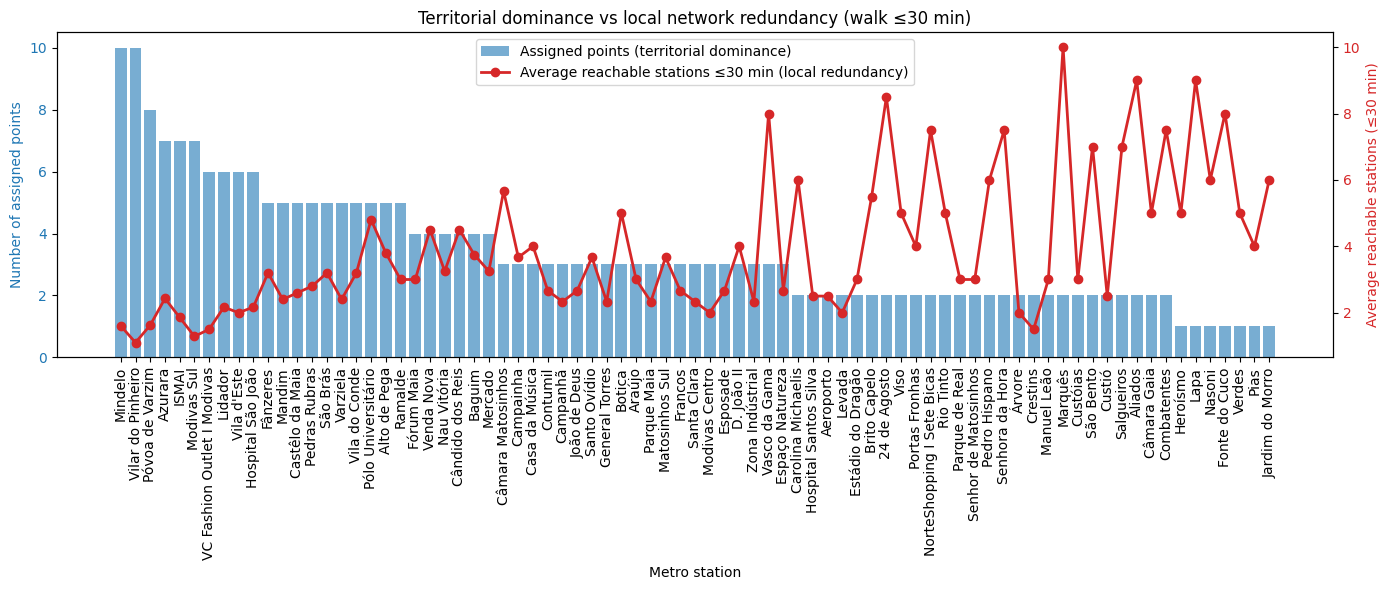

In [76]:
## WALK-based station influence (minimum-time assignment)

# Aggregate the number of origin points assigned to each station
# based on the minimum walking travel time
freq = (
    df_final
    .groupby("best_station_walk")
    .size()
    .reset_index(name="count_points")
    .sort_values("count_points", ascending=False)
)

freq = freq.merge(
    stops_gdf[["stop_id", "stop_name"]],
    left_on="best_station_walk",
    right_on="stop_id",
    how="left"
)

freq = freq[["best_station_walk", "stop_name", "count_points"]]

inverse_metric = (
    df_final
    .groupby("best_station_walk")["n_metro_30min_walk"]
    .mean()
    .reset_index(name="avg_access_30min")
)

inverse_metric = inverse_metric.merge(
    stops_gdf[["stop_id", "stop_name"]],
    left_on="best_station_walk",
    right_on="stop_id",
    how="left"
)

inverse_metric = inverse_metric.set_index("best_station_walk")
freq_indexed = freq.set_index("best_station_walk")

inverse_metric = inverse_metric.loc[freq_indexed.index].reset_index()

# Plot territorial dominance and local network redundancy per station,
# comparing the number of assigned points with the average number
# of reachable stations (≤30 min) for those assigned origins
fig, ax1 = plt.subplots(figsize=(14, 6))

# First metric: territorial dominance
color1 = "tab:blue"
bars = ax1.bar(
    freq["stop_name"],
    freq["count_points"],
    color=color1,
    alpha=0.6,
    label="Assigned points (territorial dominance)"
)

plt.xticks(rotation=90)

ax1.set_xlabel("Metro station")
ax1.set_ylabel("Number of assigned points", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# Second metric: local redundancy
ax2 = ax1.twinx()

color2 = "tab:red"
line = ax2.plot(
    freq["stop_name"],
    inverse_metric["avg_access_30min"],
    color=color2,
    marker="o",
    linewidth=2,
    label="Average reachable stations ≤30 min (local redundancy)"
)

ax2.set_ylabel("Average reachable stations (≤30 min)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper center")

plt.title("Territorial dominance vs local network redundancy (walk ≤30 min)")

plt.tight_layout()
plt.show()

# This chart compares station-level territorial dominance and local network redundancy.
# Bars represent the number of origin points assigned to each station under a
# minimum walking-time allocation rule, while the line shows the average number
# of reachable stations (≤30 min) for those assigned points. The inverse pattern
# between both metrics reflects the structural trade-off between spatial dominance
# and network redundancy within the metro system in Porto.

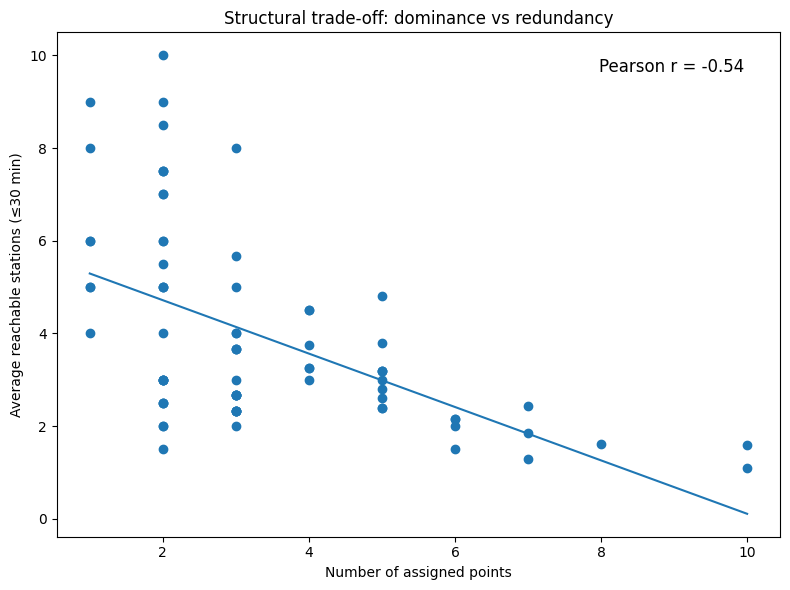

In [77]:
## Examine the structural relationship between territorial dominance
## and local network redundancy at the station level

x = freq["count_points"].values
y = inverse_metric["avg_access_30min"].values

# Estimate linear relationship between dominance and redundancy
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

# Compute Pearson correlation coefficient
corr = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.plot(sorted(x), trend(sorted(x)))

plt.text(
    0.95, 0.95,
    f"Pearson r = {corr:.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.xlabel("Number of assigned points")
plt.ylabel("Average reachable stations (≤30 min)")
plt.title("Structural trade-off: dominance vs redundancy")

plt.tight_layout()
plt.show()

# This scatter plot examines the structural relationship between territorial
# dominance (number of assigned points) and local network redundancy
# (average reachable stations ≤30 min) across stations. The negative correlation
# highlights an emergent trade-off: stations that dominate larger exclusive
# territories tend to serve areas with fewer alternative connections, while
# stations in highly redundant network environments exhibit lower territorial
# exclusivity

In [78]:
## Create station-level walk influence zones and add assigned point counts.

df_geo = df_final.merge(
    points[["point_id", "geometry"]],
    on="point_id",
    how="left"
)

df_geo = gpd.GeoDataFrame(
    df_geo,
    geometry="geometry",
    crs=PROJECT_CRS
)

zones = df_geo.dissolve(by="best_station_walk")
zones = zones.reset_index()
zones = zones.merge(
    freq[["best_station_walk", "count_points"]],
    on="best_station_walk",
    how="left"
)

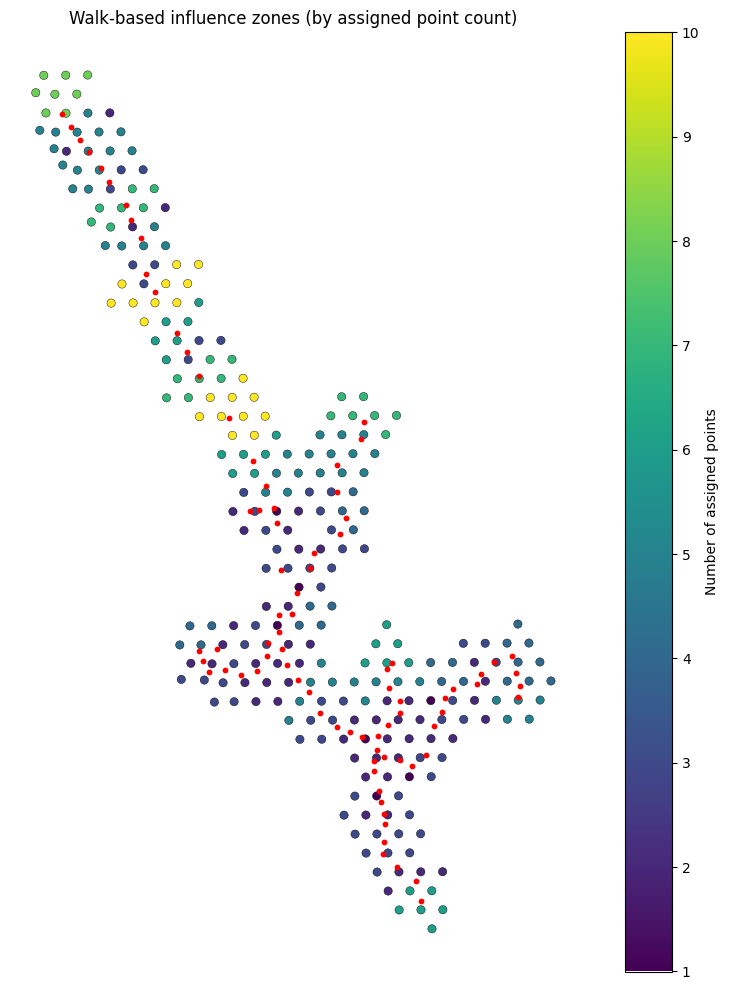

In [79]:
## Plot walk-based influence zones by number of assigned origin points.

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

zones.plot(
    column="count_points",
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Number of assigned points"},
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

stops_gdf.plot(
    ax=ax,
    color="red",
    markersize=10
)

ax.set_title("Walk-based influence zones (by assigned point count)")
ax.axis("off")

plt.tight_layout()
plt.show()

In [80]:
## Export of WALK results
output_path = "/results/walk_access_metro.geojson"

# Export WALK results in the project canonical CRS (EPSG:4326)
df_geo.to_file(
    output_path,
    driver="GeoJSON"
)